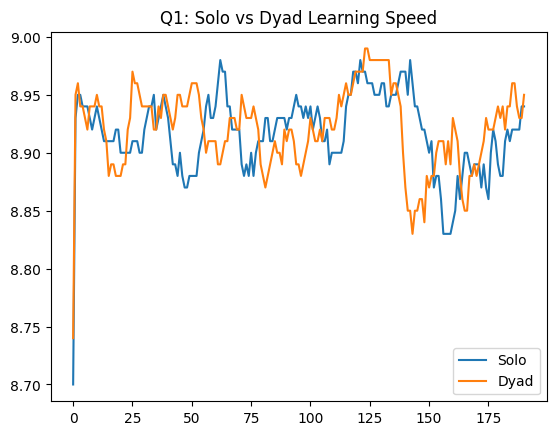

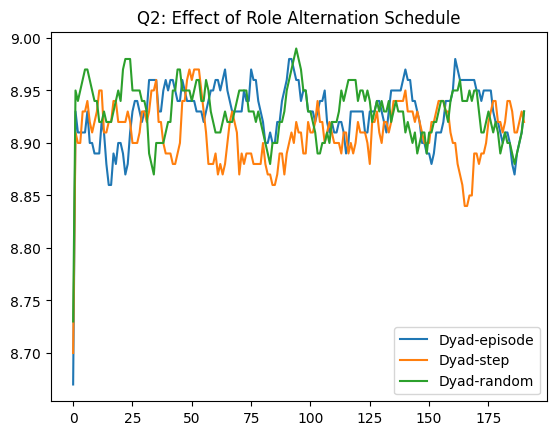

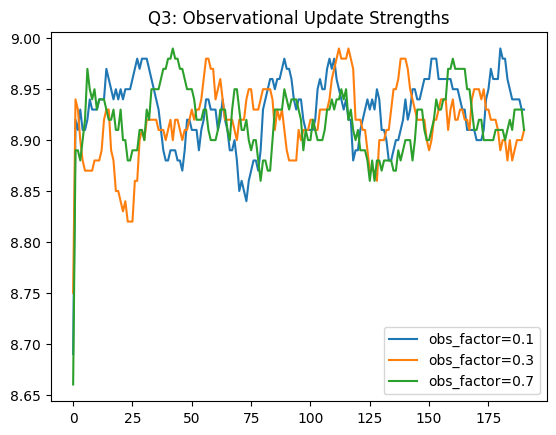

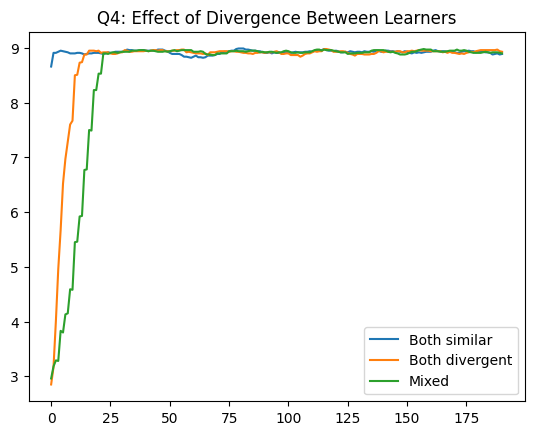

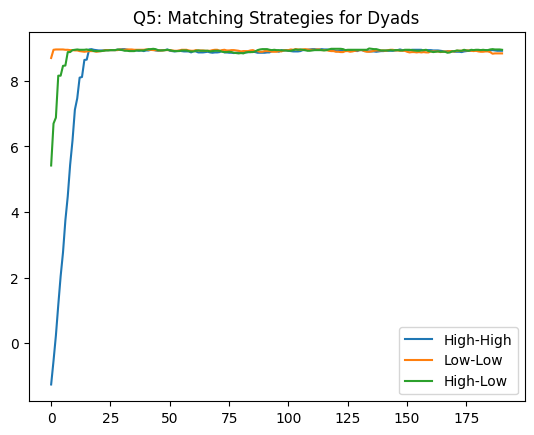

Q6: Error analysis proxy (fraction coach closer to optimal): 0.0472


In [30]:
import numpy as np
import random
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict

# A simple sequential task: a "piece" has L note positions (states),
# each requires the correct action among A possible notes/keys.
# Reward: +1 for correct move (advance to next state), -0.1 otherwise.
# Episode ends when the piece is completed (reach terminal after L correct notes)
# or when a max step budget is reached.

class PianoEnv:
    def __init__(self, length : int = 10,  n_actions: int = 5, max_steps: Optional[int] = None, seed: int = 0):
        self.length = length-1
        self.n_states = length 
        self.n_actions = n_actions
        self.state = 0
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        # "Score" mapping from state -> correct action (fixed unknown function)
        self.correct_map = [self.rng.randrange(n_actions) for _ in range(length)]
        self.max_steps = max_steps if max_steps is not None else 5 * length
        #FIXME
        allowed_actions_map = None

        # If not provided, allow all actions at all states
        if allowed_actions_map is None:
            self.allowed_actions_map = [list(range(n_actions)) for _ in range(length)]

    def reset(self) -> int:
        self.state = 0
        self.steps = 0
        return self.state

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        self.steps += 1
        done = False
        reward = -0.1
        if action == self.correct_map[self.state]:
            reward = 1.0
            self.state += 1
            if self.state >= self.length:
                done = True
        if self.steps >= self.max_steps:
            done = True
        return self.state, reward, done, {}
         
    def allowed_actions(self, state: int) -> List[int]:
        return self.allowed_actions_map[state]


# ------------------------------
# RL Agent (Q-learning)
# ------------------------------
class QLearningAgent:
    def __init__(self, n_states, n_actions, lr=0.1, gamma=0.95, eps=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.Q = np.zeros((n_states, n_actions))
        self.lr = lr
        self.gamma = gamma
        self.eps = eps

    def start_episode(self):
        pass

    def act(self, state, allowed):
        if random.random() < self.eps:
            return random.choice(allowed)
        return int(np.argmax(self.Q[state, allowed]))

    def update(self, s, a, r, s_next, done):
        best_next = np.max(self.Q[s_next])
        target = r + (0 if done else self.gamma * best_next)
        self.Q[s, a] += self.lr * (target - self.Q[s, a])

    def update_role_based(self, s, a, r, s_next, done, role="performer", obs_factor=0.3):
        if role == "performer":
            self.update(s, a, r, s_next, done)
        else:  # weaker update during observation
            best_next = np.max(self.Q[s_next])
            target = r + (0 if done else self.gamma * best_next)
            self.Q[s, a] += obs_factor * self.lr * (target - self.Q[s, a])

    def generate_action(self, state, allowed):
        return np.argmax(self.Q[state, allowed])

# ------------------------------
# Experimental Variants
# ------------------------------

def run_solo(env, agent, n_episodes=200):
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        while not done:
            a = agent.act(s, env.allowed_actions(s))
            s_next, r, done, _ = env.step(a)
            agent.update(s, a, r, s_next, done)
            ep_reward += r
            s = s_next
        rewards.append(ep_reward)
    return np.array(rewards)


def run_dyad(env, a, b, n_episodes=200, swap_mode="episode", obs_factor=0.3):
    rewards = []
    divergence = []

    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        # performer/coach choice
        performer_first_is_a = (ep % 2 == 0)
        performer = a if performer_first_is_a else b
        coach = b if performer_first_is_a else a

        while not done:
            steps += 1
            a_perform = performer.act(s, env.allowed_actions(s))
            s_next, r, done, _ = env.step(a_perform)

            performer.update_role_based(s, a_perform, r, s_next, done, role="performer")
            coach.update_role_based(s, a_perform, r, s_next, done, role="coach", obs_factor=obs_factor)

            ep_reward += r
            s = s_next

            if swap_mode == "step":
                performer, coach = coach, performer
            elif swap_mode == "random" and random.random() < 0.1:
                performer, coach = coach, performer

        rewards.append(ep_reward)

        # measure divergence
        flat_a, flat_b = a.Q.flatten(), b.Q.flatten()
        denom = (np.linalg.norm(flat_a) * np.linalg.norm(flat_b) + 1e-12)
        cos_sim = np.dot(flat_a, flat_b) / denom
        divergence.append(1.0 - cos_sim)

    return np.array(rewards), np.array(divergence)

# ------------------------------
# Experiments
# -------------------<-----------

# Q1: Solo vs Dyad
env = PianoEnv()
solo_agent = QLearningAgent(env.n_states, env.n_actions)
dyad_a = QLearningAgent(env.n_states, env.n_actions)
dyad_b = QLearningAgent(env.n_states, env.n_actions)

solo_rewards = run_solo(env, solo_agent, 200)
dyad_rewards, div = run_dyad(env, dyad_a, dyad_b, 200, swap_mode="episode")

plt.plot(np.convolve(solo_rewards, np.ones(10)/10, mode='valid'), label="Solo")
plt.plot(np.convolve(dyad_rewards, np.ones(10)/10, mode='valid'), label="Dyad")
plt.legend()
plt.title("Q1: Solo vs Dyad Learning Speed")
plt.show()

# Q2: Role alternation schedules
modes = ["episode", "step", "random"]
for mode in modes:
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    rewards, _ = run_dyad(env, a, b, 200, swap_mode=mode)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=f"Dyad-{mode}")
plt.legend()
plt.title("Q2: Effect of Role Alternation Schedule")
plt.show()

# Q3: Observational update strengths
for obs_factor in [0.1, 0.3, 0.7]:
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    rewards, _ = run_dyad(env, a, b, 200, swap_mode="episode", obs_factor=obs_factor)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=f"obs_factor={obs_factor}")
plt.legend()
plt.title("Q3: Observational Update Strengths")
plt.show()

# Q4: Divergence effects (small vs. large init differences)
def init_agent(divergent=False):
    ag = QLearningAgent(env.n_states, env.n_actions)
    if divergent:
        ag.Q = np.random.uniform(-1, 1, size=ag.Q.shape)
    return ag

pairs = [(False, False), (True, True), (False, True)]
labels = ["Both similar", "Both divergent", "Mixed"]
for (d1, d2), label in zip(pairs, labels):
    a, b = init_agent(d1), init_agent(d2)
    rewards, _ = run_dyad(env, a, b, 200)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=label)
plt.legend()
plt.title("Q4: Effect of Divergence Between Learners")
plt.show()

# Q5: Matching learners by skill (simulate by warm-starting one agent)
def run_matching(high_skill_a=True, high_skill_b=False):
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    if high_skill_a:
        a.Q += np.random.uniform(0, 1, size=a.Q.shape)
    if high_skill_b:
        b.Q += np.random.uniform(0, 1, size=b.Q.shape)
    return run_dyad(env, a, b, 200)

configs = [(True, True), (False, False), (True, False)]
labels = ["High-High", "Low-Low", "High-Low"]
for (ha, hb), label in zip(configs, labels):
    rewards, _ = run_matching(ha, hb)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=label)
plt.legend()
plt.title("Q5: Matching Strategies for Dyads")
plt.show()

# Q6: Error analysis ability (proxy)
# Measure: how often coach's greedy action differs from performer but is closer to optimal

def run_error_analysis(env, a, b, n_episodes=100):
    error_scores = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        while not done:
            action_perf = a.act(s, env.allowed_actions(s))
            action_coach = b.generate_action(s, env.allowed_actions(s))
            optimal = (s % env.n_actions)
            coach_better = (action_coach != action_perf) and (action_coach == optimal)
            error_scores.append(int(coach_better))
            s, _, done, _ = env.step(action_perf)
    return np.mean(error_scores)

A, B = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
score = run_error_analysis(env, A, B)
print("Q6: Error analysis proxy (fraction coach closer to optimal):", score)
